# Multi-branch MLP regressor - intermediate integration

This notebook implements a multi-branch MLP regressor using the intermediate integration approach. In this approach, each input modality is processed through its own branch of the network, and the outputs of these branches are concatenated and passed through additional layers to produce the final output.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
import pyarrow
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

In [2]:
project_root = Path.cwd().parent
print(project_root)

c:\Users\joddy\repos\plasticell_multiomics_integration


## Data processing

In [3]:
# import pre-processed data
lcms_data = pd.read_feather(project_root / '00_data' / 'raw' / 'processed' / 'lcms.feather')
miRNA_data = pd.read_feather(project_root / '00_data' / 'raw' / 'processed' / 'miRNA.feather')
olink_data = pd.read_feather(project_root / '00_data' / 'raw' / 'processed' / 'olink.feather')
scRNA_data = pd.read_feather(project_root / '00_data' / 'raw' / 'processed' / 'scRNA.feather')
combined_metadata = pd.read_feather(project_root / '00_data' / 'raw' / 'processed' / 'combined_metadata.feather')
nk_cell_proportions = pd.read_csv(project_root / '00_data' / 'nk_cell_proportions_run_4.csv')

In [4]:
# Extract vessel and day numbers
nk_cell_proportions[['vessel', 'day']] = nk_cell_proportions['vessel_day'].str.extract(r'V(\d+)_D(\d+)')
nk_cell_proportions['vessel'] = pd.to_numeric(nk_cell_proportions['vessel'])
nk_cell_proportions['day'] = pd.to_numeric(nk_cell_proportions['day'])
nk_cell_proportions['label'] = 'r4_v' + nk_cell_proportions['vessel'].astype(str) + '_d' + nk_cell_proportions['day'].astype(str)
subset_nk = nk_cell_proportions[nk_cell_proportions['label'].isin(combined_metadata['label'])]

In [5]:
conditions = [
    (subset_nk['day'] >= 1) & (subset_nk['day'] <= 3),
    (subset_nk['day'] >= 4) & (subset_nk['day'] <= 6),
    (subset_nk['day'] >= 8) & (subset_nk['day'] <= 12),
    (subset_nk['day'] >= 13) & (subset_nk['day'] <= 15),
    (subset_nk['day'] >= 19) & (subset_nk['day'] <= 26),
    (subset_nk['day'] >= 29) & (subset_nk['day'] <= 36)
]

# Define the corresponding values for each condition
values = [
    'mesoderm_commitment',
    'hemogenic_endothelium',
    'early_haem',
    'late_haem',
    'early_NK',
    'late_NK'
]

# Use np.select to assign values based on conditions
subset_nk['stage'] = np.select(conditions, values, default='undefined')

C:\Users\joddy\AppData\Local\Temp\ipykernel_31420\838363551.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_nk['stage'] = np.select(conditions, values, default='undefined')


In [6]:
# Set index to 'label' and drop the column for all modalities
miRNA_data.index = miRNA_data['label']
miRNA_data = miRNA_data.drop(columns=['label'])

olink_data.index = olink_data['label']
olink_data = olink_data.drop(columns=['label'])

scRNA_data.index = scRNA_data['label']
scRNA_data = scRNA_data.drop(columns=['label'])

lcms_data.index = lcms_data['label']
lcms_data = lcms_data.drop(columns=['label'])

combined_metadata.index = combined_metadata['label']
combined_metadata = combined_metadata.drop(columns=['label'])

subset_nk = subset_nk.set_index('label').sort_index()

# Sort all omics data by their index in alphanumeric order
scRNA_data = scRNA_data.sort_index()
olink_data = olink_data.sort_index()
miRNA_data = miRNA_data.sort_index()
lcms_data = lcms_data.sort_index()
combined_metadata = combined_metadata.sort_index()

# Set subset_nk index to 'label' and sort in alphanumeric order
subset_nk = subset_nk.sort_index()

# check that the indexes match up
print(olink_data.index.equals(subset_nk.index))
print(scRNA_data.index.equals(subset_nk.index))
print(miRNA_data.index.equals(subset_nk.index))
print(lcms_data.index.equals(subset_nk.index))
print(combined_metadata.index.equals(subset_nk.index))

True
True
True
True
True


## Multi-branch MLP regressor

In [7]:
def ntile(series, n):
    # Assign ranks, then integer-divide into n bins
    return ((series.rank(method='first') - 1) // (len(series) / n)).astype(int)

# Example usage:
stratify_bins = ntile(subset_nk['proportion_NK'], 4).astype(str)

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader

# Convert DataFrames to numpy arrays
X_miRNA = miRNA_data.values.astype(np.float32)
X_olink = olink_data.values.astype(np.float32)
X_scRNA = scRNA_data.values.astype(np.float32)
X_lcms = lcms_data.values.astype(np.float32)

y = subset_nk['proportion_NK'].values.astype(np.float32)


In [9]:
class MultiOmicsDataset(Dataset):
    def __init__(self, X_miRNA, X_olink, X_scRNA, X_lcms, y):
        self.X_miRNA = torch.tensor(X_miRNA, dtype=torch.float32)
        self.X_olink = torch.tensor(X_olink, dtype=torch.float32)
        self.X_scRNA = torch.tensor(X_scRNA, dtype=torch.float32)
        self.X_lcms = torch.tensor(X_lcms, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (self.X_miRNA[idx],
                self.X_olink[idx],
                self.X_scRNA[idx],
                self.X_lcms[idx],
                self.y[idx])

In [10]:
class MultiOmicsRegressor(nn.Module):
    def __init__(self, dims, hidden_dim=64, latent_dim=32):
        super().__init__()
        self.enc_miRNA = nn.Sequential(
            nn.Linear(dims[0], hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim), nn.ReLU()
        )
        self.enc_olink = nn.Sequential(
            nn.Linear(dims[1], hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim), nn.ReLU()
        )
        self.enc_scRNA = nn.Sequential(
            nn.Linear(dims[2], hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim), nn.ReLU()
        )
        self.enc_lcms = nn.Sequential(
            nn.Linear(dims[3], hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim), nn.ReLU()
        )
        self.regressor = nn.Sequential(
            nn.Linear(latent_dim*4, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x_miRNA, x_olink, x_scRNA, x_lcms):
        z1 = self.enc_miRNA(x_miRNA)
        z2 = self.enc_olink(x_olink)
        z3 = self.enc_scRNA(x_scRNA)
        z4 = self.enc_lcms(x_lcms)
        z = torch.cat([z1, z2, z3, z4], dim=1)
        return self.regressor(z).squeeze()


In [11]:
dataset = MultiOmicsDataset(X_miRNA, X_olink, X_scRNA, X_lcms, y)

# 80/20 split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

model = MultiOmicsRegressor(
    dims=[X_miRNA.shape[1], X_olink.shape[1], X_scRNA.shape[1], X_lcms.shape[1]]
)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ----- Training loop -----
train_losses, val_losses = [], []
val_r2_scores, val_rmse_scores = [], []

for epoch in range(50):
    model.train()
    running_loss = 0.0
    for X_miRNA_b, X_olink_b, X_scRNA_b, X_lcms_b, y_b in train_loader:
        optimizer.zero_grad()
        preds = model(X_miRNA_b, X_olink_b, X_scRNA_b, X_lcms_b)
        loss = criterion(preds, y_b)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss/len(train_loader))

    # ----- Validation -----
    model.eval()
    val_preds, val_true = [], []
    with torch.no_grad():
        for X_miRNA_b, X_olink_b, X_scRNA_b, X_lcms_b, y_b in val_loader:
            preds = model(X_miRNA_b, X_olink_b, X_scRNA_b, X_lcms_b)
            val_preds.append(preds.numpy())
            val_true.append(y_b.numpy())
    val_preds = np.concatenate(val_preds)
    val_true = np.concatenate(val_true)

    val_loss = mean_squared_error(val_true, val_preds)
    val_r2 = r2_score(val_true, val_preds)
    val_rmse = np.sqrt(val_loss)

    val_losses.append(val_loss)
    val_r2_scores.append(val_r2)
    val_rmse_scores.append(val_rmse)

    print(f"Epoch {epoch+1:02d} | "
          f"Train MSE={train_losses[-1]:.4f} | "
          f"Val MSE={val_loss:.4f} | "
          f"Val R2={val_r2:.3f} | "
          f"Val RMSE={val_rmse:.3f}")

Epoch 01 | Train MSE=0.0965 | Val MSE=0.2274 | Val R2=-0.674 | Val RMSE=0.477
Epoch 02 | Train MSE=0.0521 | Val MSE=0.0528 | Val R2=0.611 | Val RMSE=0.230
Epoch 03 | Train MSE=0.0100 | Val MSE=0.0056 | Val R2=0.959 | Val RMSE=0.075
Epoch 04 | Train MSE=0.0232 | Val MSE=0.0070 | Val R2=0.948 | Val RMSE=0.084
Epoch 05 | Train MSE=0.0203 | Val MSE=0.0018 | Val R2=0.987 | Val RMSE=0.042
Epoch 06 | Train MSE=0.0068 | Val MSE=0.0155 | Val R2=0.886 | Val RMSE=0.124
Epoch 07 | Train MSE=0.0015 | Val MSE=0.0368 | Val R2=0.729 | Val RMSE=0.192
Epoch 08 | Train MSE=0.0029 | Val MSE=0.0466 | Val R2=0.657 | Val RMSE=0.216
Epoch 09 | Train MSE=0.0055 | Val MSE=0.0415 | Val R2=0.694 | Val RMSE=0.204
Epoch 10 | Train MSE=0.0040 | Val MSE=0.0287 | Val R2=0.789 | Val RMSE=0.169
Epoch 11 | Train MSE=0.0018 | Val MSE=0.0156 | Val R2=0.885 | Val RMSE=0.125
Epoch 12 | Train MSE=0.0006 | Val MSE=0.0063 | Val R2=0.953 | Val RMSE=0.079
Epoch 13 | Train MSE=0.0009 | Val MSE=0.0029 | Val R2=0.979 | Val RMSE=0.05

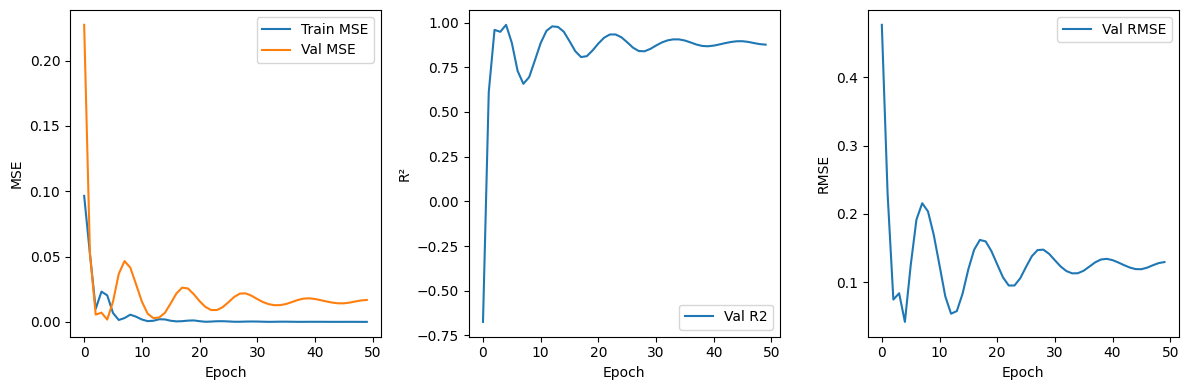

In [12]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(train_losses, label="Train MSE")
plt.plot(val_losses, label="Val MSE")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend()

plt.subplot(1,3,2)
plt.plot(val_r2_scores, label="Val R2")
plt.xlabel("Epoch"); plt.ylabel("R²"); plt.legend()

plt.subplot(1,3,3)
plt.plot(val_rmse_scores, label="Val RMSE")
plt.xlabel("Epoch"); plt.ylabel("RMSE"); plt.legend()

plt.tight_layout()
plt.show()


## Feature importances

In [13]:
# Assuming these are your pandas dataframes
feature_names = {
    "miRNA": miRNA_data.columns.tolist(),
    "Olink": olink_data.columns.tolist(),
    "scRNA": scRNA_data.columns.tolist(),
    "LCMS": lcms_data.columns.tolist()
}

In [14]:
# Convert all data to tensors
X_miRNA_tensor = torch.tensor(miRNA_data.values, dtype=torch.float32)
X_olink_tensor = torch.tensor(olink_data.values, dtype=torch.float32)
X_scRNA_tensor = torch.tensor(scRNA_data.values, dtype=torch.float32)
X_lcms_tensor = torch.tensor(lcms_data.values, dtype=torch.float32)
y_tensor = torch.tensor(subset_nk['proportion_NK'].values, dtype=torch.float32)

# Put all modalities in a list for convenience
x_batch = [X_miRNA_tensor, X_olink_tensor, X_scRNA_tensor, X_lcms_tensor]
y_batch = y_tensor

In [15]:
def compute_saliency(model, x_batch, y_batch):
    model.eval()
    saliencies = []

    # Make each modality require gradients
    x_batch_grads = [x.clone().detach().requires_grad_(True) for x in x_batch]
    
    pred = model(*x_batch_grads).squeeze()
    loss = ((pred - y_batch)**2).mean()
    loss.backward()

    for x in x_batch_grads:
        saliency = x.grad.abs().mean(dim=0).detach().cpu().numpy()
        saliencies.append(saliency)
    
    return saliencies

saliency_scores = compute_saliency(model, x_batch, y_batch)

# Map back to feature names
saliency_dict = {modality: dict(zip(feature_names[modality], saliency_scores[i]))
                 for i, modality in enumerate(feature_names)}


In [16]:
from sklearn.metrics import r2_score
import numpy as np

def permutation_importance(model, x_batch, y_batch, n_repeats=3):
    model.eval()
    x_cat = torch.cat(x_batch, dim=1)
    y_true = y_batch.numpy()
    baseline_pred = model(*x_batch).detach().numpy()
    baseline_score = r2_score(y_true, baseline_pred)
    
    importances = np.zeros(x_cat.shape[1])
    
    for i in range(x_cat.shape[1]):
        scores = []
        for _ in range(n_repeats):
            x_perm = x_cat.clone().numpy()
            np.random.shuffle(x_perm[:, i])
            x_perm_tensor = torch.tensor(x_perm, dtype=torch.float32)
            
            # split back into modalities
            splits = [b.shape[1] for b in x_batch]
            x_perm_list = torch.split(x_perm_tensor, splits, dim=1)
            
            pred = model(*x_perm_list).detach().numpy()
            scores.append(r2_score(y_true, pred))
        
        importances[i] = baseline_score - np.mean(scores)
    
    return importances

perm_importances = permutation_importance(model, x_batch, y_batch, n_repeats=3)


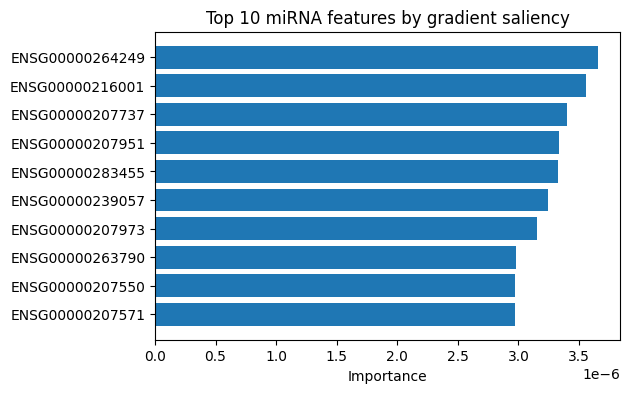

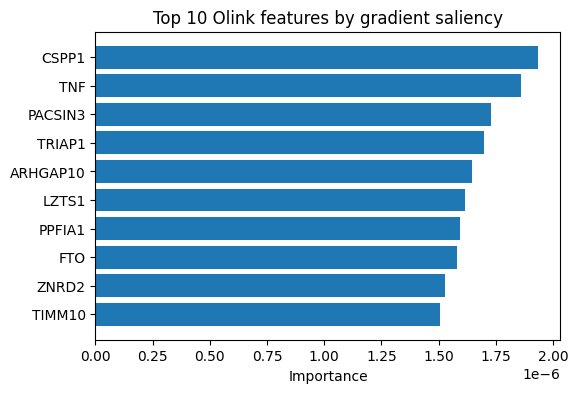

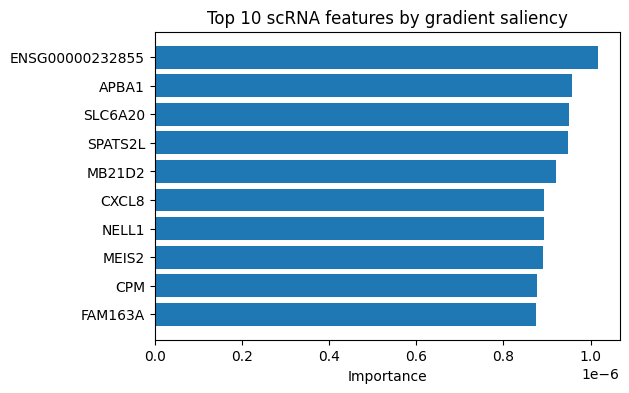

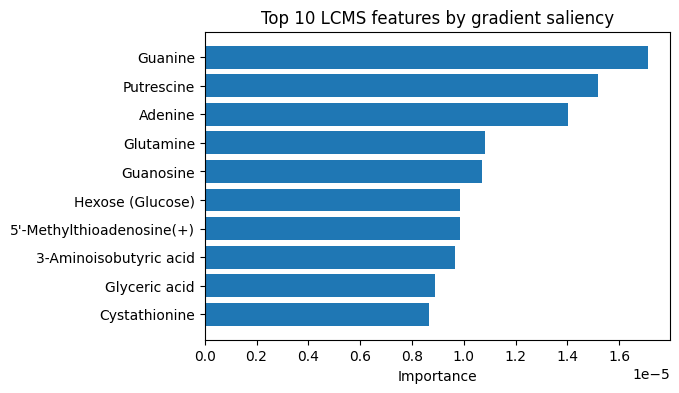

In [17]:
import matplotlib.pyplot as plt

for i, modality in enumerate(feature_names):
    scores = saliency_scores[i]
    names = feature_names[modality]
    
    # Get top 10 features
    top_idx = np.argsort(scores)[-10:][::-1]
    plt.figure(figsize=(6,4))
    plt.barh([names[j] for j in top_idx], scores[top_idx])
    plt.title(f"Top 10 {modality} features by gradient saliency")
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.show()


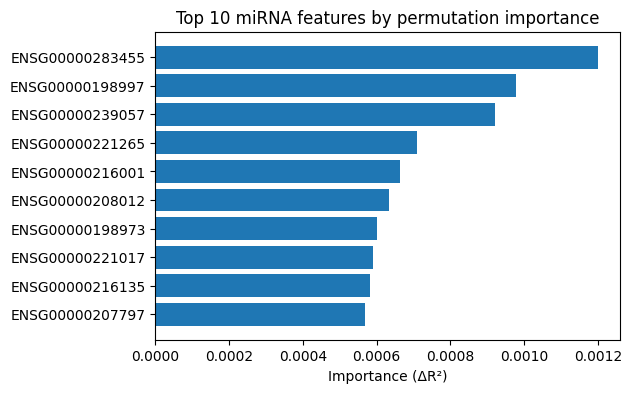

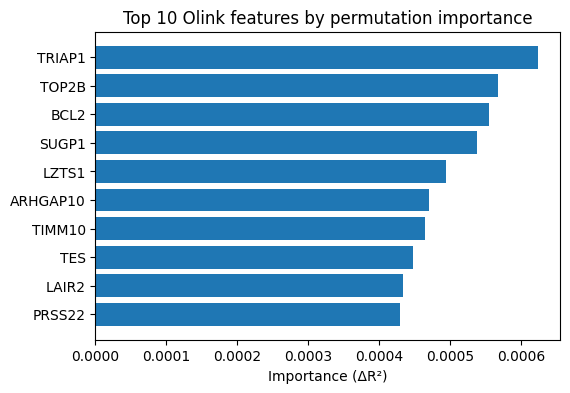

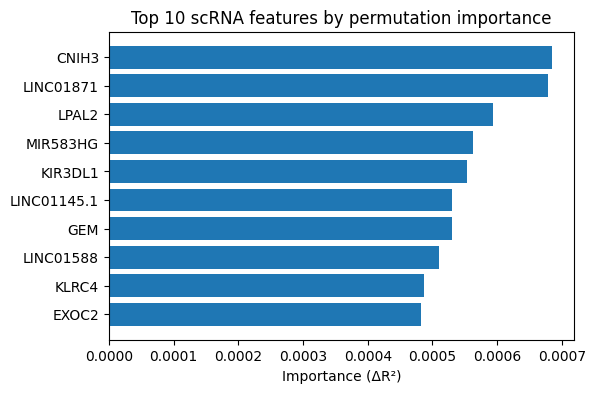

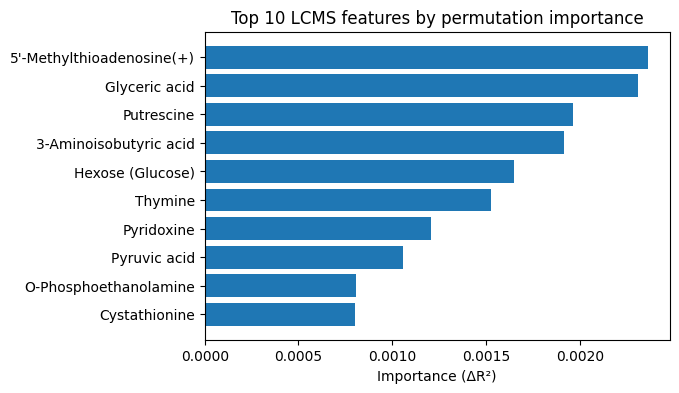

In [18]:
# First, get number of features per modality
splits = [len(f) for f in feature_names.values()]  # e.g., [336, 58, 3938, 1010]
start = 0

for i, modality in enumerate(feature_names):
    n_feat = splits[i]
    end = start + n_feat
    
    # Slice permutation importances for this modality
    scores = perm_importances[start:end]
    names = feature_names[modality]
    
    # Get top 10 features
    top_idx = np.argsort(scores)[-10:][::-1]
    
    plt.figure(figsize=(6,4))
    plt.barh([names[j] for j in top_idx], scores[top_idx])
    plt.title(f"Top 10 {modality} features by permutation importance")
    plt.xlabel("Importance (ΔR²)")
    plt.gca().invert_yaxis()
    plt.show()
    
    start = end  # update for next modality

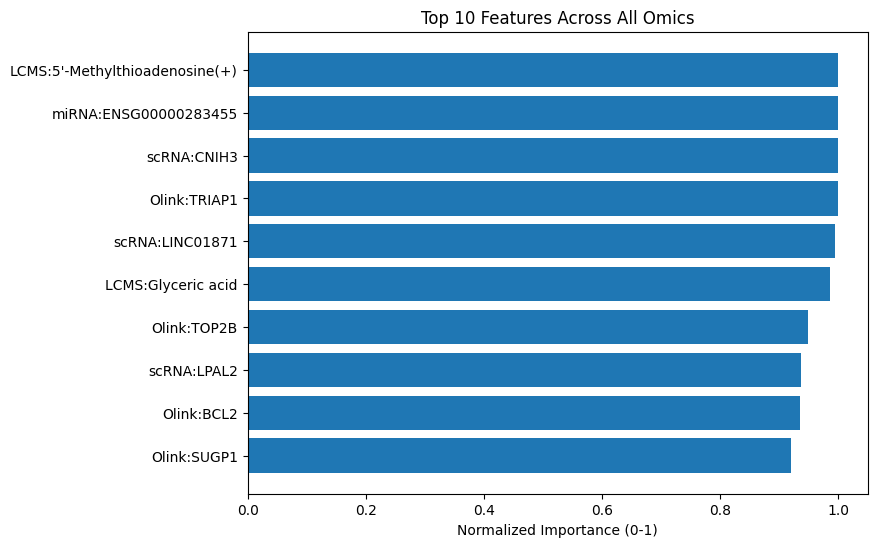

In [19]:
# Example: using permutation importances
# If you want gradient saliency instead, just replace perm_importances with saliency_scores concatenated

# 1. Concatenate importances across modalities
all_scores = []
all_names = []
splits = [len(f) for f in feature_names.values()]
start = 0

for i, modality in enumerate(feature_names):
    n_feat = splits[i]
    end = start + n_feat
    
    scores = perm_importances[start:end]  # or saliency_scores[i] for gradient
    names = feature_names[modality]
    
    # Normalize 0-1 within modality
    scores_norm = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)
    
    all_scores.extend(scores_norm)
    all_names.extend([f"{modality}:{n}" for n in names])
    
    start = end

# 2. Pick top 10 globally
all_scores = np.array(all_scores)
top_idx = np.argsort(all_scores)[-10:][::-1]

top_names = [all_names[i] for i in top_idx]
top_scores = all_scores[top_idx]

# 3. Plot
plt.figure(figsize=(8,6))
plt.barh(top_names, top_scores)
plt.xlabel("Normalized Importance (0-1)")
plt.title("Top 10 Features Across All Omics")
plt.gca().invert_yaxis()
plt.show()


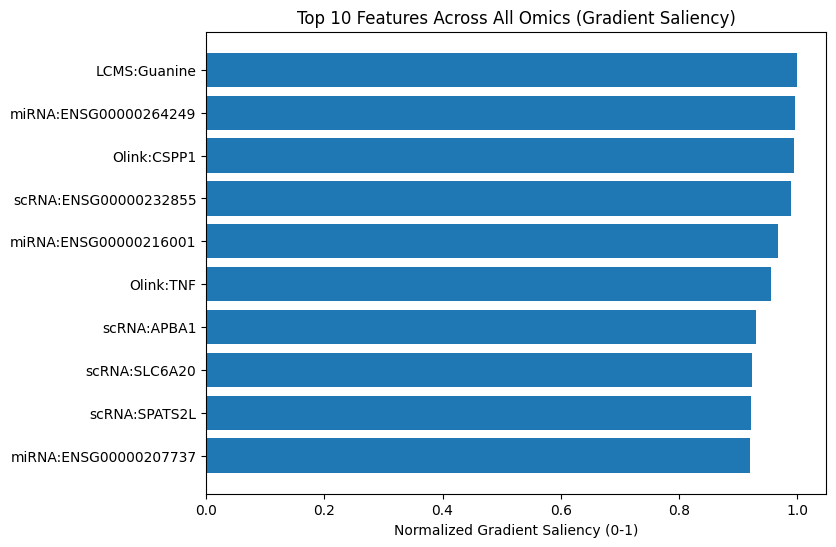

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Concatenate normalized saliency scores across modalities
all_scores = []
all_names = []

for i, modality in enumerate(feature_names):
    scores = saliency_scores[i]  # gradient saliency for this modality
    names = feature_names[modality]
    
    # Normalize 0-1 within modality
    scores_norm = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)
    
    all_scores.extend(scores_norm)
    all_names.extend([f"{modality}:{n}" for n in names])

# 2. Pick top 10 globally
all_scores = np.array(all_scores)
top_idx = np.argsort(all_scores)[-10:][::-1]

top_names = [all_names[i] for i in top_idx]
top_scores = all_scores[top_idx]

# 3. Plot
plt.figure(figsize=(8,6))
plt.barh(top_names, top_scores)
plt.xlabel("Normalized Gradient Saliency (0-1)")
plt.title("Top 10 Features Across All Omics (Gradient Saliency)")
plt.gca().invert_yaxis()
plt.show()
